<a href="https://colab.research.google.com/github/noor-gh06/Cybercrime-DataMining/blob/main/phase3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Cybercrime Data Mining Project - phase 3

1. Problem

This project aims to analyze cybercrime incidents using data mining techniques in order to extract meaningful patterns and insights from the dataset.
The main objective is to predict the attack outcome using classification techniques, and to explore hidden structures in the data using clustering.

With the continuous growth of cybercrime activities, analyzing such datasets is important to better understand attack behavior and support more effective security decision-making.

2. Data Mining Task

This project involves two main data mining tasks:

Classification: to build a predictive model that estimates the target variable (outcome) based on the input features.
Clustering: to group similar records together without using the target label, in order to discover hidden patterns in the dataset.

3. Data

The dataset used is the Cyber Crimes Dataset, which contains approximately 100,000 records and 15 attributes describing different cybercrime incidents.

It includes both numerical and categorical features such as attack type, target system, attack duration, severity, response time, and data compromised.

The target variable for the classification task is outcome.

Overall, the dataset is considered suitable for both classification and clustering tasks due to its size and diversity, although the complexity of cybercrime data may affect model performance

4. Data Preprocessing

The dataset was preprocessed in Phase 2 to improve data quality and model performance.

The main preprocessing steps included:

Converting the timestamp attribute into meaningful features (year, month, hour)
Removing high-cardinality attributes (attacker_ip, target_ip) to reduce noise
Applying One-Hot Encoding for categorical variables
Handling missing values appropriately
Standardizing numerical features for better clustering performance

These steps were essential to reduce noise, improve consistency, and prepare the dataset for effective data mining.

5. Data Mining Technique

Two main techniques were applied in this phase:

Decision Tree Classification

Decision Tree was used as the classification model with two attribute selection measures:

Gini Index
Entropy

The model was evaluated using different train-test splits:

90% / 10%
80% / 20%
70% / 30%

Evaluation metrics included:

Accuracy
Confusion Matrix
Decision Tree Visualization
K-Means Clustering

K-Means clustering was applied to group similar records.

Different values of K were tested:

K = 2
K = 3
K = 4

Evaluation was performed using:

WCSS (Elbow Method)
Silhouette Score
Cluster Visualization

In [35]:
# Upload the dataset file from the local device to Google Colab
from google.colab import files
uploaded = files.upload()

Saving Preprocessed_dataset.csv to Preprocessed_dataset (1).csv


### Data Loading and Preparation

In this step, the required libraries were imported, and the preprocessed dataset from Phase 2 was loaded into the environment.

The dataset was then inspected by displaying the first few rows to verify that it was loaded correctly and to gain an initial understanding of its structure, including the feature names and data types.

This step is important to ensure that the dataset is properly prepared before applying any machine learning models, and that no issues exist in the data format that could affect the analysis.

In [ ]:
# Import required libraries for data handling and model preparation
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
# Load the preprocessed dataset from Phase 2
df_phase3 = pd.read_csv("Preprocessed_dataset.csv")
# Display the first few rows to verify the dataset structure
df_phase3.head()

,outcome,data_compromised_GB,attack_duration_min,attack_severity,response_time_min,year,month,hour,attack_type_Brute Force,attack_type_Cross-Site Scripting,...,industry_Government,industry_Healthcare,industry_Manufacturing,industry_Retail,industry_Technology,mitigation_method_Block IP,mitigation_method_Containment,mitigation_method_Patch,mitigation_method_Quarantine,mitigation_method_Reset Credentials
0,Failure,-1.205448,1.717105,-1.219286,1.416923,2024,4,11,False,False,...,False,False,False,False,False,False,True,False,False,False
1,Success,0.519862,1.048385,1.568458,-0.509669,2024,2,20,False,False,...,False,False,False,True,False,False,False,False,False,True
2,Success,-0.037204,-0.358233,0.523054,-0.066553,2024,7,18,False,False,...,False,False,False,False,False,False,False,False,True,False
3,Failure,-1.171455,1.555690,-0.870818,-1.299572,2023,12,0,False,False,...,False,True,False,False,False,False,False,True,False,False
4,Failure,1.304125,-1.695674,0.174586,0.742616,2024,7,5,False,False,...,False,False,False,False,False,False,True,False,False,False


The dataset was successfully loaded, and the preview confirms that the structure is consistent with the preprocessing performed in Phase 2.

At this stage, the data appears clean and ready for modeling, as no immediate issues such as missing values or incorrect formats are observed in the displayed sample.

### Dataset Structure Inspection
In this step, the structure of the dataset was examined by displaying its shape and column names.
This helps in understanding the size of the dataset in terms of the number of records and features, which is important before applying any data mining techniques.

Knowing the dataset size also provides an initial indication of whether the data is sufficient for training machine learning models

In [ ]:
# Display dataset shape and columns
print("Shape of final dataset:", df_phase3.shape)
print("\nColumns:")
print(df_phase3.columns.tolist())

Shape of final dataset: (100000, 59)

Columns:
['outcome', 'data_compromised_GB', 'attack_duration_min', 'attack_severity', 'response_time_min', 'year', 'month', 'hour', 'attack_type_Brute Force', 'attack_type_Cross-Site Scripting', 'attack_type_DDoS', 'attack_type_Malware', 'attack_type_Phishing', 'attack_type_Ransomware', 'attack_type_SQL Injection', 'attack_type_Zero-Day Exploit', 'target_system_API', 'target_system_Cloud Service', 'target_system_Database', 'target_system_Email Server', 'target_system_IoT Device', 'target_system_Network Switch', 'target_system_User Account', 'target_system_Web Server', 'security_tools_used_Antivirus', 'security_tools_used_Endpoint Detection', 'security_tools_used_Firewall', 'security_tools_used_IDS', 'security_tools_used_MFA', 'security_tools_used_SIEM', 'security_tools_used_VPN', 'security_tools_used_WAF', 'user_role_Admin', 'user_role_Contractor', 'user_role_Employee', 'user_role_External User', 'location_Australia', 'location_Brazil', 'location_C

The dataset contains a large number of records (around 100,000) and multiple features, which makes it suitable for both classification and clustering tasks.

The presence of multiple attributes allows the model to capture different aspects of cybercrime incidents, although not all features may contribute equally to prediction performance

### Feature Selection and Target Definition
In this step, the dataset was divided into input features (X) and the target variable (y).
The target variable is outcome, which will be used in the classification task, while the remaining attributes are used as input features.

Additionally, the class distribution of the target variable was examined to understand whether the dataset is balanced or imbalanced. This is a critical step, as class imbalance can significantly affect the performance of classification models..

In [ ]:
# Separate features and target variable
X = df_phase3.drop("outcome", axis=1)
y = df_phase3["outcome"]
# Display shapes and class distribution
print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nClass distribution:")
print(y.value_counts())

X shape: (100000, 58)
y shape: (100000,)

Class distribution:
outcome
Success    50030
Failure    49970
Name: count, dtype: int64


The dataset was successfully split into features and target variable, with a large number of samples and features available for training.

From the class distribution, it can be observed that the dataset is balanced, as the Success and Failure classes have almost equal numbers of records. Therefore, class imbalance is not the main reason for the low classification performance.

### Data Preparation for Clustering
In this step, the dataset was prepared for clustering by removing the target variable (outcome), since clustering is an unsupervised learning technique that does not rely on labeled data.

Only the feature set was retained to allow the clustering algorithm to group similar records based on their inherent characteristics rather than predefined classes

In [ ]:
# Prepare data for clustering by removing the target variable
X_clustering = df_phase3.drop("outcome", axis=1)
# Display shape of clustering data
print("Clustering data shape:", X_clustering.shape)

Clustering data shape: (100000, 58)


The resulting dataset maintains the same number of records while reducing the number of features by excluding the target variable.

This ensures that the clustering process is unbiased and driven purely by the relationships between the input features, which allows for discovering hidden patterns that may not be captured by classification

### Train-Test Split (90/10)
In this step, the dataset was split into training and testing sets using a 90/10 ratio.
The training set is used to build the model, while the testing set is used to evaluate its performance on unseen data.

A higher proportion of training data (90%) allows the model to learn more patterns from the dataset, which may improve its performance, especially when dealing with complex data such as cybercrime incidents.

Stratified sampling was applied to preserve the class distribution in both training and testing sets. This is important to ensure that the evaluation is fair and not biased due to uneven class representation.

In [ ]:
# Split dataset into training and testing sets (90/10)
X_train_90, X_test_10, y_train_90, y_test_10 = train_test_split(
    X, y,
    test_size=0.10,
    random_state=42,
    stratify=y
)
# Display shapes of the split datasets
print("90/10 split:")
print("X_train_90:", X_train_90.shape)
print("X_test_10 :", X_test_10.shape)
print("y_train_90:", y_train_90.shape)
print("y_test_10 :", y_test_10.shape)

90/10 split:
X_train_90: (90000, 58)
X_test_10 : (10000, 58)
y_train_90: (90000,)
y_test_10 : (10000,)


The split results confirm that the majority of the data is used for training, which is beneficial for learning. However, using a smaller test set may make the evaluation slightly less stable.

The use of stratification ensures that both sets maintain similar class distributions, which is particularly important if the dataset is imbalanced, as it prevents misleading evaluation results.

### Train-Test Split (80/20)


In this step, the dataset was split into training and testing sets using an 80/20 ratio.
Compared to the previous 90/10 split, this configuration allocates more data for testing, which allows for a more reliable and stable evaluation of the model’s performance.

However, reducing the size of the training set may slightly limit the model’s ability to learn complex patterns from the data.

Stratified sampling was applied to ensure that the class distribution remains consistent across both training and testing sets, maintaining fairness in evaluation.

In [ ]:
# Split dataset into training and testing sets (80/20)
X_train_80, X_test_20, y_train_80, y_test_20 = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
# Display shapes of the split datasets
print("80/20 split:")
print("X_train_80:", X_train_80.shape)
print("X_test_20 :", X_test_20.shape)
print("y_train_80:", y_train_80.shape)
print("y_test_20 :", y_test_20.shape)

80/20 split:
X_train_80: (80000, 58)
X_test_20 : (20000, 58)
y_train_80: (80000,)
y_test_20 : (20000,)


This split provides a balance between training and testing, making it useful for comparing model performance under different data proportions.

In the later results, it is expected that the model performance may slightly differ from the 90/10 split due to the reduced training data and increased test size, which can reveal how sensitive the model is to the amount of training data.

### Train-Test Split (70/30)

In this step, the dataset was split into training and testing sets using a 70/30 ratio.
This configuration allocates the largest portion of data for testing among all splits, which allows for a more robust and reliable evaluation of the model’s generalization performance.

However, reducing the training data to 70% may limit the model’s ability to learn complex patterns, especially in datasets with high variability such as cybercrime data.

Stratified sampling was applied to preserve the class distribution in both sets, ensuring that the evaluation remains fair and representative.

In [ ]:
# Split dataset into training and testing sets (70/30)
X_train_70, X_test_30, y_train_70, y_test_30 = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)
# Display shapes of the split datasets
print("70/30 split:")
print("X_train_70:", X_train_70.shape)
print("X_test_30 :", X_test_30.shape)
print("y_train_70:", y_train_70.shape)
print("y_test_30 :", y_test_30.shape)

70/30 split:
X_train_70: (70000, 58)
X_test_30 : (30000, 58)
y_train_70: (70000,)
y_test_30 : (30000,)


This split emphasizes evaluation over training, making it useful for testing how well the model performs on unseen data.

By comparing the results of all three splits (90/10, 80/20, and 70/30), it becomes possible to analyze how sensitive the model is to the amount of training data, and whether increasing test size leads to more reliable performance estimates.

### Importing Libraries for Classification

In this step, the required libraries for Decision Tree classification were imported.

These libraries are used to build the classification model, evaluate its performance using accuracy and confusion matrix, and visualize the structure of the decision tree to better understand how the model makes

In [ ]:
# Import libraries for Decision Tree model and evaluation
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

The imported libraries provide all the tools needed for the classification task, including model training, performance evaluation, and visual interpretation.

### Decision Tree Training (90/10 - Gini)

In this step, a Decision Tree classifier was trained using the Gini Index as the splitting criterion on the 90/10 dataset split.

The model learns patterns from the training data by recursively splitting the features based on impurity reduction, aiming to create homogeneous groups of the target variable (outcome).

Using the Gini Index allows the model to select splits that minimize class impurity, which helps in building an efficient decision structure.

In [ ]:
#Model Training (90/10 Split)
#Trains Decision Tree using Gini on 90/10 split
model_90 = DecisionTreeClassifier(criterion='gini')
model_90.fit(X_train_90, y_train_90)

DecisionTreeClassifier()

The model has been successfully trained and is now capable of capturing patterns from the dataset.

However, Decision Trees are prone to overfitting, especially when trained on a large portion of data (such as 90%), which may lead to high performance on training data but weaker generalization on unseen data.

### Prediction (90/10 Split)

In this step, the trained Decision Tree model was used to generate predictions on the testing dataset.

This step is essential to evaluate how well the model generalizes to unseen data, as the test set was not used during training.

The predicted values will later be compared with the actual target values to assess the model’s performance using evaluation metrics such as accuracy and confusion matrix.

In [ ]:
# Make predictions using the trained model on test data
y_pred_90 = model_90.predict(X_test_10)

The model successfully generated predictions for the test data.
This indicates that the training process was completed correctly, and the model is ready for performance evaluation.

However, the quality of these predictions cannot be judged without comparing them to the actual values, which will be done in the next step.

### Model Evaluation - Accuracy (90/10)

In this step, the accuracy of the Decision Tree model was calculated using the testing dataset.

Accuracy represents the proportion of correctly predicted instances out of the total predictions, providing a general measure of model performance.

However, accuracy alone may not fully reflect the model’s effectiveness, especially if the dataset is imbalanced, as the model may achieve a reasonable accuracy by favoring the majority class.

In [ ]:
# Calculate accuracy of the model
acc_90 = accuracy_score(y_test_10, y_pred_90)
print("Accuracy (90/10):", acc_90)

Accuracy (90/10): 0.4993



The obtained accuracy is approximately (0.4993), which indicates that the model has limited predictive performance.

This relatively low accuracy suggests that the model is not effectively capturing the relationship between features and the target variable.

Possible reasons for this include:

The dataset may contain complex or noisy patterns
The selected features may not provide strong predictive power
The classes may be imbalanced, affecting the model’s learning

This result highlights the need to analyze the model further using additional metrics such as the confusion matrix.

### Confusion Matrix (90/10)

In this step, the confusion matrix was used to evaluate the performance of the Decision Tree model in more detail.

The confusion matrix provides a breakdown of predictions by showing the number of correctly and incorrectly classified instances for each class. This allows for a deeper understanding of how the model performs across different classes.

Unlike accuracy, which gives an overall measure, the confusion matrix reveals whether the model is biased toward a particular class or struggles to correctly classify certain categories.

In [ ]:
# Generate confusion matrix
cm_90 = confusion_matrix(y_test_10, y_pred_90)
print("Confusion Matrix (90/10):\n", cm_90)

Confusion Matrix (90/10):
 [[2498 2499]
 [2508 2495]]


From the confusion matrix, it can be observed that the model correctly classifies a portion of the instances, but also makes a significant number of misclassifications.

This indicates that the model has difficulty distinguishing between classes, which is consistent with the relatively low accuracy observed earlier.

In particular, the model may be biased toward predicting the majority class, leading to more correct predictions for that class while performing poorly on the minority class.

This behavior suggests that the dataset characteristics (such as class imbalance or overlapping features) may be limiting the model’s performance.

### Decision Tree Visualization (90/10)

In this step, the trained Decision Tree model was visualized to better understand how it makes decisions.

The tree structure illustrates how different features are used to split the data into smaller subsets, leading to final predictions. Each node represents a decision based on a feature, and the branches represent possible outcomes.

The tree depth was limited to improve readability and focus on the most important decision rules, although this does not fully represent the complete complexity of the model.

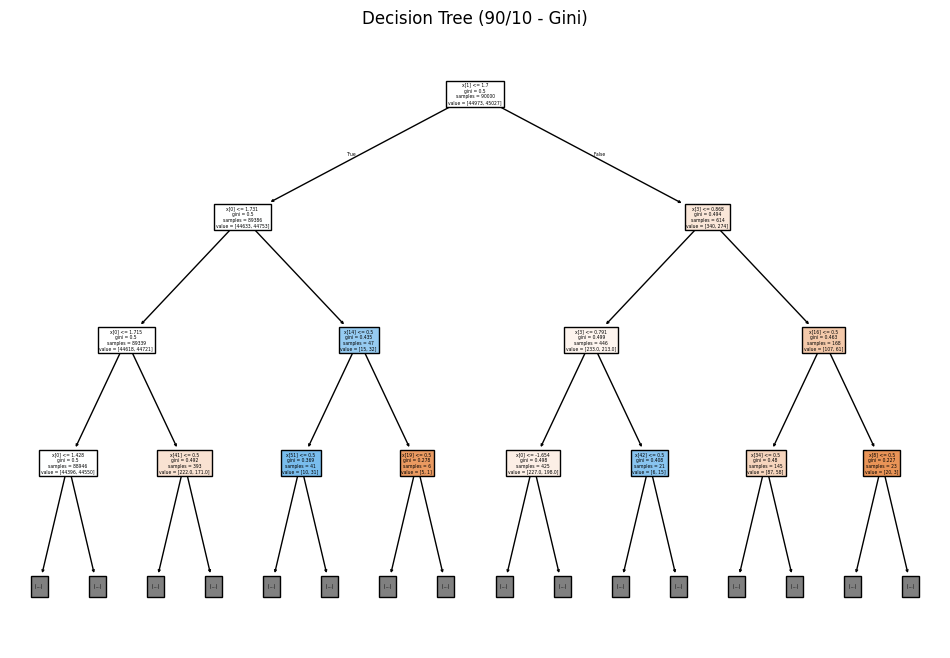

In [ ]:
# Visualize the Decision Tree model
plt.figure(figsize=(12,8))
plot_tree(model_90, filled=True, max_depth=3)
plt.title("Decision Tree (90/10 - Gini)")
plt.show()

From the visualization, it can be observed that certain features play a more significant role in the decision-making process, as they appear near the top levels of the tree.

This indicates that these features have a stronger influence on predicting the target variable (outcome).

However, the presence of multiple splits and branches also suggests that the relationships within the data are complex, which may contribute to the model’s limited accuracy observed earlier.

### Decision Tree (80/20 - Gini)

In this step, the Decision Tree model was trained and evaluated using the 80/20 data split with the Gini Index as the splitting criterion.

The model was trained on the training set and then evaluated on the testing set using accuracy and confusion matrix. The tree was also visualized to better understand the decision-making process.

This configuration provides a more balanced evaluation compared to the 90/10 split, as a larger test set allows for a more reliable assessment of model performance.

Accuracy (80/20): 0.49965
Confusion Matrix (80/20):
 [[4926 5068]
 [4939 5067]]


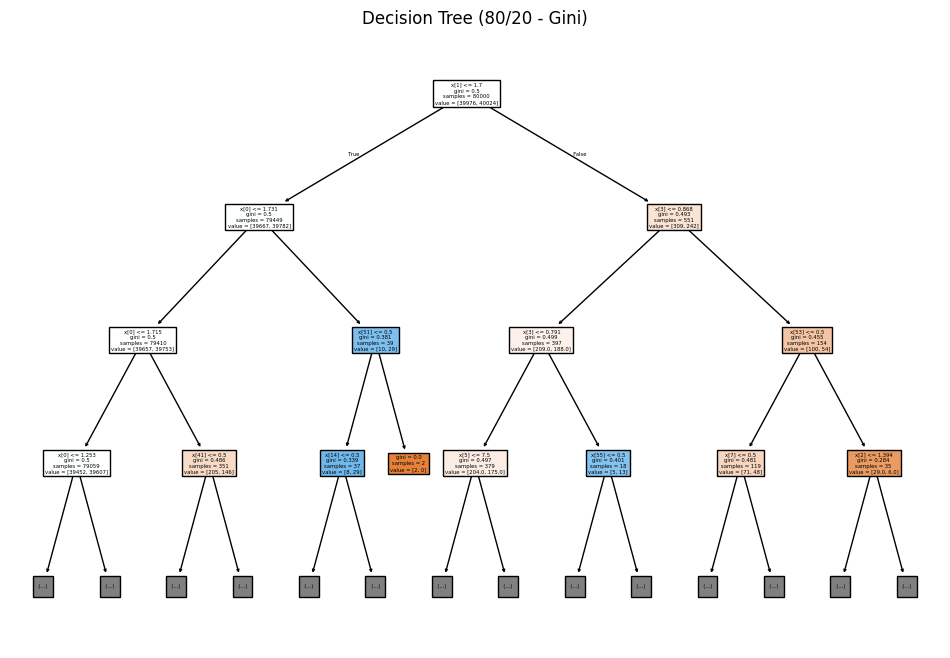

In [ ]:
# Train, predict, evaluate, and visualize Decision Tree (80/20)
model_80 = DecisionTreeClassifier(criterion='gini')
model_80.fit(X_train_80, y_train_80)

y_pred_80 = model_80.predict(X_test_20)

acc_80 = accuracy_score(y_test_20, y_pred_80)
print("Accuracy (80/20):", acc_80)

cm_80 = confusion_matrix(y_test_20, y_pred_80)
print("Confusion Matrix (80/20):\n", cm_80)

plt.figure(figsize=(12,8))
plot_tree(model_80, filled=True, max_depth=3)
plt.title("Decision Tree (80/20 - Gini)")
plt.show()

The obtained accuracy is approximately (0.49965), which remains relatively close to the accuracy observed in the 90/10 split.

This similarity in performance suggests that increasing the test size did not significantly improve the model’s predictive ability, indicating that the model’s limitations are likely related to the data itself rather than the split configuration.

The confusion matrix shows that the model still makes a considerable number of misclassifications, reinforcing the observation that it struggles to distinguish between classes.

Overall, the results indicate that the model performance is stable across different splits but remains relatively weak.

### Decision Tree (70/30 - Gini)

In this step, the Decision Tree model was trained and evaluated using the 70/30 data split with the Gini Index.

This configuration uses the largest testing set among all splits, which allows for a more robust evaluation of the model’s generalization ability. However, reducing the training data may limit the model’s capacity to learn complex patterns.

The model was evaluated using accuracy and confusion matrix, and the tree was visualized to understand its structure.

Accuracy (70/30): 0.4961
Confusion Matrix (70/30):
 [[7478 7513]
 [7604 7405]]


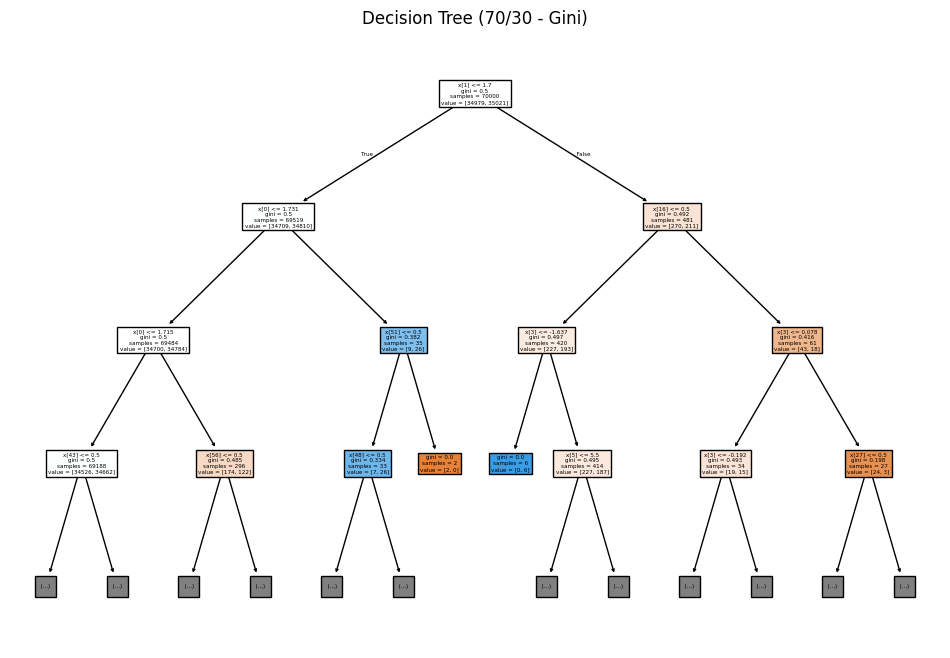

In [ ]:
# Train, predict, evaluate, and visualize Decision Tree (70/30)
model_70 = DecisionTreeClassifier(criterion='gini')
model_70.fit(X_train_70, y_train_70)

y_pred_70 = model_70.predict(X_test_30)

acc_70 = accuracy_score(y_test_30, y_pred_70)
print("Accuracy (70/30):", acc_70)

cm_70 = confusion_matrix(y_test_30, y_pred_70)
print("Confusion Matrix (70/30):\n", cm_70)

plt.figure(figsize=(12,8))
plot_tree(model_70, filled=True, max_depth=3)
plt.title("Decision Tree (70/30 - Gini)")
plt.show()

The obtained accuracy is approximately (0.4961), which is again very close to the results obtained from the 90/10 and 80/20 splits.

This consistency across all splits indicates that the model performance is stable regardless of the training size. However, the overall accuracy remains relatively low, suggesting that the model is not effectively capturing the relationship between features and the target variable.

The confusion matrix confirms that the model continues to make a significant number of misclassifications, which indicates difficulty in distinguishing between classes.

Overall, increasing the test size did not lead to a meaningful improvement in performance, reinforcing the conclusion that the main limitation lies in the dataset characteristics rather than the data split.

### Decision Tree using Entropy

In this section, the Decision Tree classifier was applied again using Entropy as the attribute selection measure instead of the Gini Index.

The purpose of this step is to compare the effect of different splitting criteria on model performance. While Gini measures impurity directly, Entropy is based on information gain and aims to select splits that provide the highest reduction in uncertainty.

The same train-test splits were used to ensure a fair comparison with the previous Gini-based models.

In [ ]:
# Decision Tree using Entropy

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

Using Entropy allows us to examine whether information gain leads to better classification performance on this dataset compared to Gini.

This comparison is important because both criteria may produce similar results, but the dataset characteristics can make one criterion slightly more effective than the other.

### Decision Tree (90/10 - Entropy)

In this step, the Decision Tree model was trained and evaluated using the Entropy criterion on the 90/10 split.

Entropy measures impurity based on information gain, aiming to select splits that reduce uncertainty in the data. Compared to Gini, Entropy may produce slightly different decision boundaries depending on the dataset.

The model was evaluated using accuracy and confusion matrix, and the tree was visualized to understand the decision structure.

Accuracy (90/10 - Entropy): 0.5065
Confusion Matrix (90/10 - Entropy):
 [[2530 2467]
 [2468 2535]]


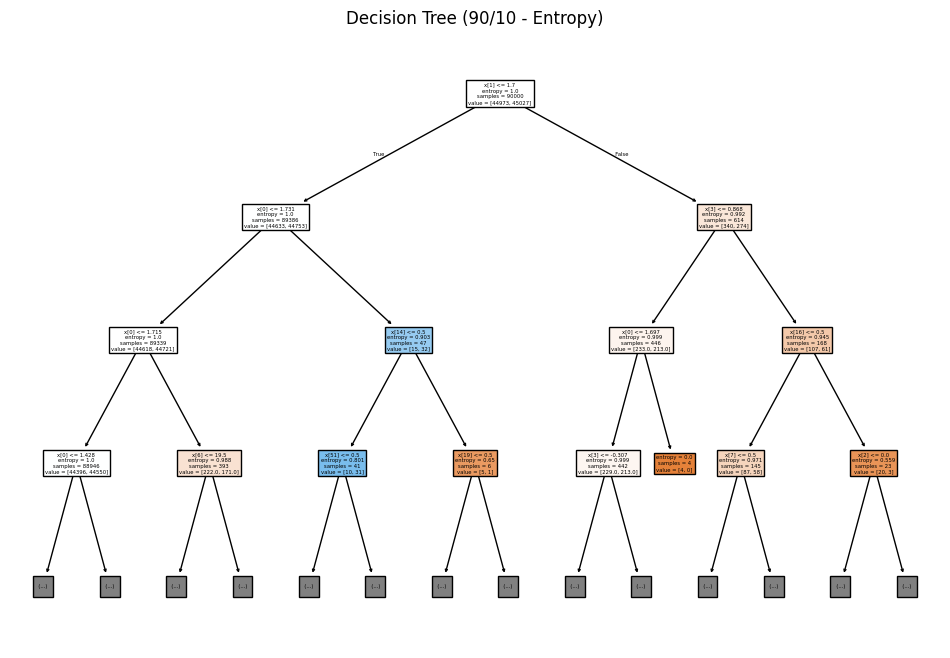

In [ ]:
# Train, predict, evaluate, and visualize Decision Tree (90/10 - Entropy)
model_90_e = DecisionTreeClassifier(criterion='entropy')
model_90_e.fit(X_train_90, y_train_90)

y_pred_90_e = model_90_e.predict(X_test_10)

acc_90_e = accuracy_score(y_test_10, y_pred_90_e)
print("Accuracy (90/10 - Entropy):", acc_90_e)

cm_90_e = confusion_matrix(y_test_10, y_pred_90_e)
print("Confusion Matrix (90/10 - Entropy):\n", cm_90_e)

plt.figure(figsize=(12,8))
plot_tree(model_90_e, filled=True, max_depth=3)
plt.title("Decision Tree (90/10 - Entropy)")
plt.show()


The obtained accuracy is approximately (0.5065), which is very close to the accuracy obtained using the Gini Index.

This indicates that changing the splitting criterion from Gini to Entropy did not significantly improve the model’s performance on this dataset.

The confusion matrix also shows a similar pattern of misclassifications, suggesting that the model continues to struggle in distinguishing between classes regardless of the splitting method.

This implies that the limitation is not due to the choice of splitting criterion, but rather due to the dataset characteristics, such as feature quality or class distribution.

### Decision Tree (80/20 - Entropy)

In this step, the Decision Tree model was trained and evaluated using the Entropy criterion on the 80/20 split.

This configuration provides a larger testing set compared to the 90/10 split, which allows for a more reliable evaluation of the model’s performance.

The model was evaluated using accuracy and confusion matrix, and the tree was visualized to analyze the decision structure.


Accuracy (80/20 - Entropy): 0.50235
Confusion Matrix (80/20 - Entropy):
 [[5013 4981]
 [4972 5034]]


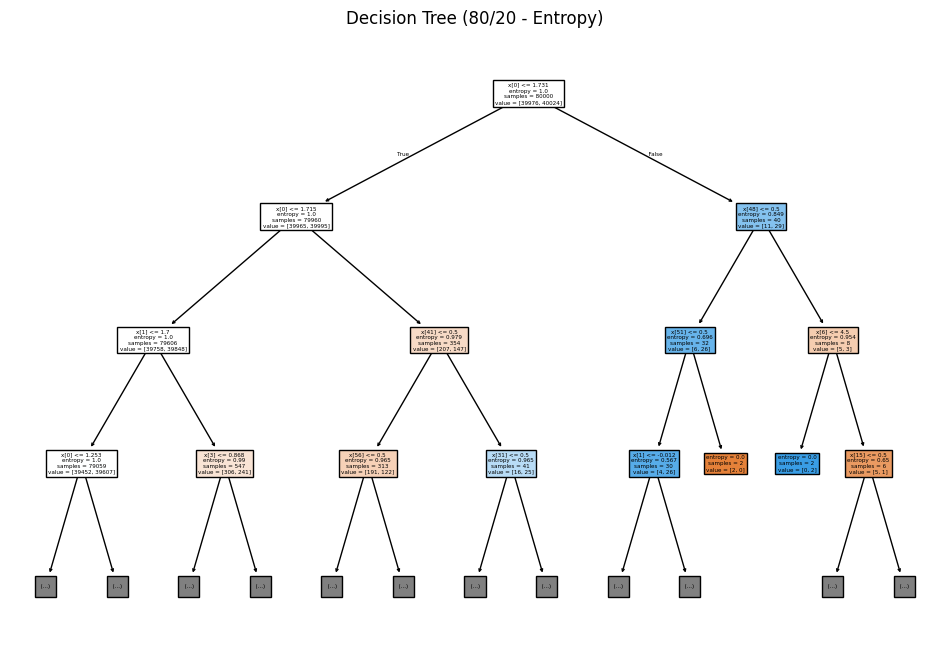

In [ ]:
# Train, predict, evaluate, and visualize Decision Tree (80/20 - Entropy)
model_80_e = DecisionTreeClassifier(criterion='entropy')
model_80_e.fit(X_train_80, y_train_80)

y_pred_80_e = model_80_e.predict(X_test_20)

acc_80_e = accuracy_score(y_test_20, y_pred_80_e)
print("\nAccuracy (80/20 - Entropy):", acc_80_e)

cm_80_e = confusion_matrix(y_test_20, y_pred_80_e)
print("Confusion Matrix (80/20 - Entropy):\n", cm_80_e)

plt.figure(figsize=(12,8))
plot_tree(model_80_e, filled=True, max_depth=3)
plt.title("Decision Tree (80/20 - Entropy)")
plt.show()


The obtained accuracy is approximately (0.50235), which is very similar to both:

the Gini result for the same split (80/20), and
the Entropy result for the 90/10 split.

This consistency indicates that neither the choice of splitting criterion (Gini vs Entropy) nor the change in data split has a significant impact on the model’s performance.

The confusion matrix shows a similar pattern of misclassifications, confirming that the model continues to struggle in separating the classes.

Overall, these results reinforce the conclusion that the model performance is stable but relatively weak, and the limitation is likely due to the dataset rather than the model configuration.

### Decision Tree (70/30 - Entropy)

In this step, the Decision Tree model was trained and evaluated using the Entropy criterion on the 70/30 split.

This configuration uses the largest testing set, allowing for a more comprehensive evaluation of the model’s generalization ability, while reducing the amount of training data.

The model was evaluated using accuracy and confusion matrix, and the tree was visualized to analyze the decision structure.


Accuracy (70/30 - Entropy): 0.49706666666666666
Confusion Matrix (70/30 - Entropy):
 [[7444 7547]
 [7541 7468]]


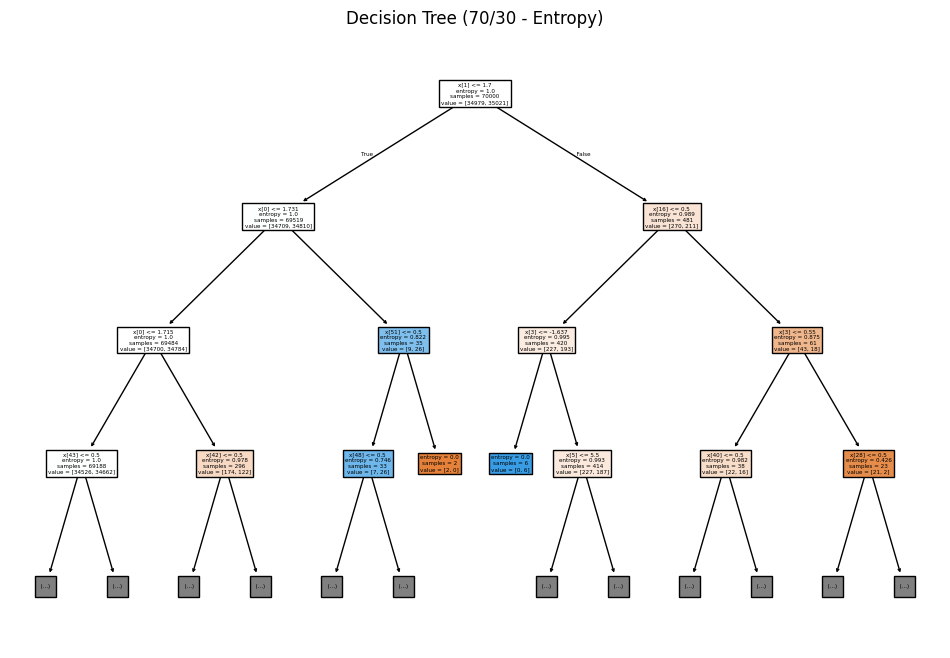

In [ ]:

# Train, predict, evaluate, and visualize Decision Tree (70/30 - Entropy)
model_70_e = DecisionTreeClassifier(criterion='entropy')
model_70_e.fit(X_train_70, y_train_70)

y_pred_70_e = model_70_e.predict(X_test_30)

acc_70_e = accuracy_score(y_test_30, y_pred_70_e)
print("\nAccuracy (70/30 - Entropy):", acc_70_e)

cm_70_e = confusion_matrix(y_test_30, y_pred_70_e)
print("Confusion Matrix (70/30 - Entropy):\n", cm_70_e)

plt.figure(figsize=(12,8))
plot_tree(model_70_e, filled=True, max_depth=3)
plt.title("Decision Tree (70/30 - Entropy)")
plt.show()

The obtained accuracy is approximately (0.49706666666666666), which is again very similar to all previous results across both Gini and Entropy criteria and different data splits.

This consistent pattern indicates that neither the choice of splitting criterion nor the variation in train-test split significantly affects the model’s performance.

The confusion matrix also shows similar misclassification behavior, confirming that the model struggles to distinguish between classes regardless of configuration.

Overall, the results demonstrate that the model performance is stable but relatively weak, and the main limitation lies in the dataset characteristics rather than the model or its parameters.

### Reloading Dataset for Clustering

In this step, the dataset is reloaded for the clustering task.

Although the dataset has already been preprocessed in Phase 2, it is reloaded here to ensure a clean and independent workflow for clustering, separate from the classification process.

The same preprocessed dataset is used, as it has already been cleaned and transformed, making it suitable for clustering algorithms.

In [ ]:
# Reload original dataset for clustering
df = pd.read_csv("Preprocessed_dataset.csv")

The dataset was successfully reloaded, and it maintains the same structure and preprocessing applied earlier.

This ensures consistency in the analysis and allows clustering to be performed on clean and well-prepared data.

### Data Preparation for Clustering

In this step, only numerical features were selected from the dataset, as clustering algorithms such as K-Means rely on distance calculations and therefore require numerical input.

Missing values were handled by replacing them with the mean of each column to avoid errors during clustering and to maintain consistency in the data.

This preprocessing step ensures that the dataset is suitable for applying K-Means and that all features contribute properly to distance calculations.

In [ ]:
# Select numeric columns and handle missing values
# Keep only numeric columns for clustering and fill missing values
data = df.select_dtypes(include=['number']).fillna(df.select_dtypes(include=['number']).mean())
# Display dataset shape and preview
print(data.shape)
data.head()

(100000, 7)


,data_compromised_GB,attack_duration_min,attack_severity,response_time_min,year,month,hour
0,-1.205448,1.717105,-1.219286,1.416923,2024,4,11
1,0.519862,1.048385,1.568458,-0.509669,2024,2,20
2,-0.037204,-0.358233,0.523054,-0.066553,2024,7,18
3,-1.171455,1.555690,-0.870818,-1.299572,2023,12,0
4,1.304125,-1.695674,0.174586,0.742616,2024,7,5


The resulting dataset contains only numerical features, making it fully compatible with the K-Means algorithm.

By handling missing values, the dataset becomes more stable and prevents issues during clustering, ensuring that all records are considered in the analysis.

However, using mean imputation may slightly affect the natural distribution of the data, which could influence clustering results

### Finding Optimal K using WCSS

In this step, the Within-Cluster Sum of Squares (WCSS) was calculated for different values of K (2, 3, and 4).

WCSS measures the compactness of clusters by calculating the sum of squared distances between data points and their corresponding cluster centroids. Lower WCSS values indicate more compact clusters.

By evaluating WCSS across different values of K, we can observe how cluster compactness improves as the number of clusters increases, which helps in identifying the optimal number of clusters using the Elbow Method.

In [ ]:
# Import libraries for clustering and evaluation
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Calculate WCSS for different K values
wcss = []
K_values = [2, 3, 4]

for k in K_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(data)
    wcss.append(kmeans.inertia_)

print("WCSS:", wcss)

WCSS: [2801423.972413996, 2135918.3111068956, 1779264.9854663962]


The WCSS values decrease as K increases, which is expected because increasing the number of clusters naturally reduces the distance between data points and their centroids.

However, the rate of decrease becomes smaller after a certain point, indicating diminishing returns. This point, known as the "elbow," suggests the optimal number of clusters.

From the observed values, The reduction in WCSS appears to slow down after K = 3, indicating that adding more clusters beyond this point does not significantly improve cluster compactness.

### Elbow Method Visualization

In this step, the Elbow Method was visualized by plotting WCSS values against different numbers of clusters (K).

The plot shows how WCSS decreases as K increases. The goal is to identify the point where the rate of decrease slows down significantly, which represents the optimal number of clusters.

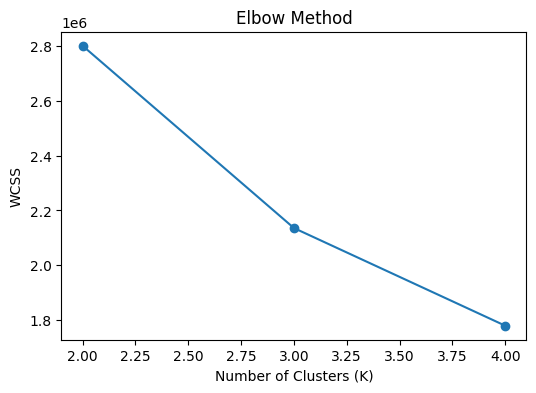

In [ ]:
# Plot Elbow Method
plt.figure(figsize=(6,4))
plt.plot(K_values, wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

From the Elbow plot, it can be observed that the WCSS decreases sharply from K=2 to K=3, and then the rate of decrease becomes smaller from K=3 to K=4.

This indicates that the improvement in cluster compactness becomes less significant after K = 3, suggesting that adding more clusters beyond this point does not provide substantial benefit.

Therefore, K = 3 can be considered a reasonable choice based on the Elbow Method

### Silhouette Score Evaluation

In this step, the Silhouette Score was calculated to evaluate the quality of clustering for different values of K.

The Silhouette Score measures how well each data point fits within its cluster compared to other clusters. Higher values indicate better separation and more well-defined clusters.

To improve efficiency, a sample of 10,000 records was used while still maintaining reliable evaluation results

In [ ]:
# Calculate Silhouette Score using a sample

sample_data = data.sample(n=10000, random_state=42)

for k in K_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(sample_data)
    score = silhouette_score(sample_data, labels)
    print(f"K = {k}, Silhouette Score = {score:.4f}")

K = 2, Silhouette Score = 0.4501
K = 3, Silhouette Score = 0.3240
K = 4, Silhouette Score = 0.2933


The Silhouette Scores obtained are approximately:

- K = 2 → (0.4501)
- K = 3 → (0.3240)
- K = 4 → (0.2933)

It can be observed that K = 2 achieves the highest Silhouette Score, indicating that it provides the best cluster separation among all tested values.

This suggests that the dataset naturally forms two well-defined groups, while increasing the number of clusters leads to less distinct and more overlapping clusters.

Although the Elbow Method suggested K = 3 as a reasonable choice, the Silhouette Score provides stronger evidence that K = 2 is the optimal number of clusters.

### Final K-Means Model

In this step, the optimal number of clusters (K) was selected based on the evaluation using both the Elbow Method and Silhouette Score.

Although the Elbow Method suggested that K = 3 could be a reasonable choice, the Silhouette Score indicated that K = 2 provides better cluster separation and more well-defined groups.

Therefore, K = 2 was selected as the final number of clusters, and the K-Means model was built accordingly.

In [ ]:
# Build final K-Means model using best K
best_k = 2

# Build final K-Means model
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)

# Fit model and get cluster labels
labels = kmeans.fit_predict(data)

print("Final model built with K =", best_k)

Final model built with K = 2


In this step, the optimal number of clusters (K) was selected based on the evaluation using both the Elbow Method and Silhouette Score.

Although the Elbow Method suggested that K = 3 could be a reasonable choice, the Silhouette Score indicated that K = 2 provides better cluster separation and more well-defined groups.

Therefore, K = 2 was selected as the final number of clusters, and the K-Means model was built accordingly

### Cluster Visualization

In this step, the clustering results were visualized using the first two numerical features.

Each data point represents a record, and different colors indicate different clusters assigned by the K-Means model.

Since clustering is performed on multiple features, this 2D visualization provides only a simplified view of the actual clustering structure.

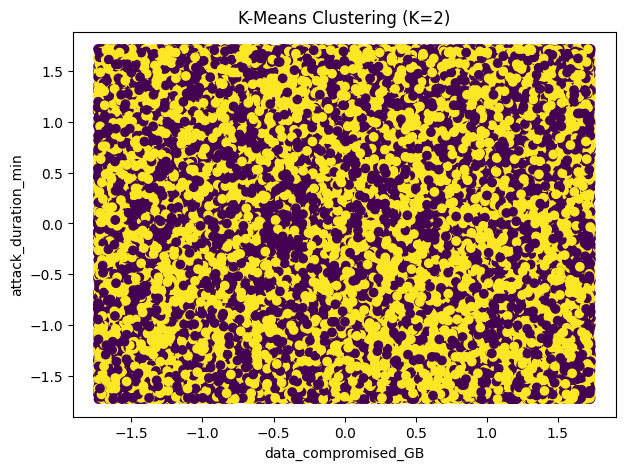

In [ ]:
# Visualize clusters using first two features
plt.figure(figsize=(7,5))
plt.scatter(data.iloc[:, 0], data.iloc[:, 1], c=labels)
plt.title(f"K-Means Clustering (K={best_k})")
plt.xlabel(data.columns[0])
plt.ylabel(data.columns[1])
plt.show()

From the visualization, the data points appear to be divided into two main groups, which supports the earlier selection of K = 2.

There is some visible separation between the clusters, although slight overlap may exist due to the complexity of the data and the limitation of visualizing only two features.

This observation confirms that the clustering model has identified distinguishable patterns in the dataset, even if they are not perfectly separated.

In this section, the clustering results are visualized for different values of K (K = 2, 3, and 4).
These visualizations help in understanding how the data points are grouped under different cluster configurations and support the selection of the optimal number of clusters.

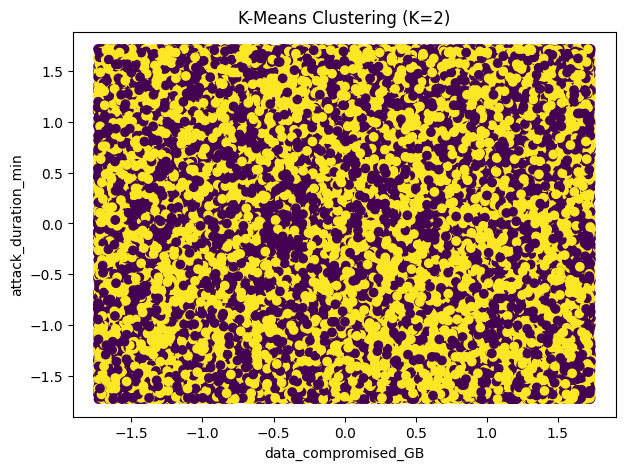

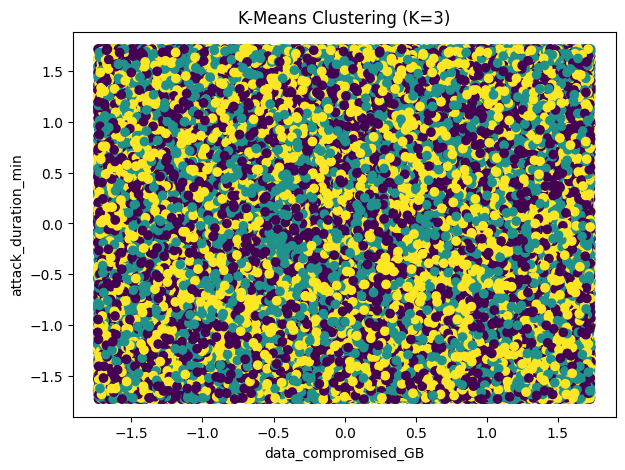

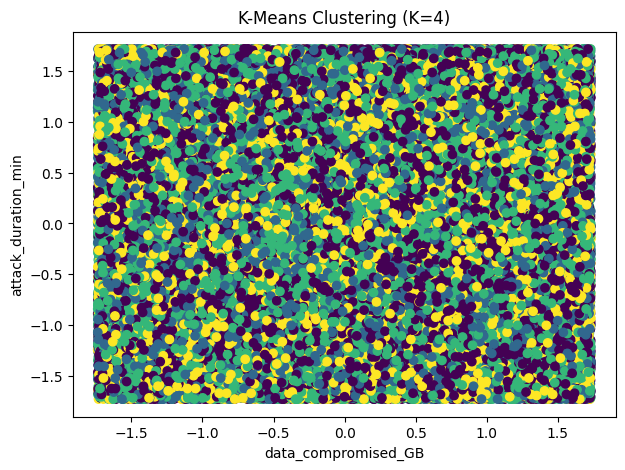

In [36]:
# Visualize clusters for each K
for k in K_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(data)

    plt.figure(figsize=(7,5))
    plt.scatter(data.iloc[:, 0], data.iloc[:, 1], c=labels)
    plt.title(f"K-Means Clustering (K={k})")
    plt.xlabel(data.columns[0])
    plt.ylabel(data.columns[1])
    plt.show()

From the visualizations, it can be observed that when K = 2, the data points are grouped into two main clusters, although the separation is not very sharp due to the complexity of the data.

As K increases to 3 and 4, the clusters become more fragmented and overlapping, indicating that increasing the number of clusters does not necessarily improve the quality of grouping.

This observation aligns with the Silhouette Score results, where K = 2 achieved the highest score, suggesting better-defined clusters. Therefore, K = 2 is considered the most appropriate choice for this dataset.

### Clustering Results Summary

K-Means clustering was applied using three values of K: 2, 3, and 4.

The Silhouette Scores were:

- K = 2 → 0.4501
- K = 3 → 0.3240
- K = 4 → 0.2933

The highest score was achieved at K = 2, indicating that this configuration provides the best cluster separation.

Although the Elbow Method suggested that K = 3 could be a reasonable choice, the Silhouette Score provided stronger evidence that K = 2 is the optimal number of clusters.

Overall, the results indicate that the dataset naturally forms two distinct groups, and clustering was able to reveal meaningful patterns within the data.

### Classification Results Comparison

In this step, the accuracy results of all Decision Tree models are summarized in a single table.

The comparison includes different data splits (90/10, 80/20, 70/30) and both splitting criteria (Gini and Entropy).

This helps organize the classification results and prepare them for comparison.

In [ ]:
# Create a comparison table for classification results
classification_results = pd.DataFrame({
    "Criterion": ["Gini", "Gini", "Gini", "Entropy", "Entropy", "Entropy"],
    "Split": ["90/10", "80/20", "70/30", "90/10", "80/20", "70/30"],
    "Accuracy": [acc_90, acc_80, acc_70, acc_90_e, acc_80_e, acc_70_e]
})

classification_results

,Criterion,Split,Accuracy
0,Gini,90/10,0.499300
1,Gini,80/20,0.499650
2,Gini,70/30,0.496100
3,Entropy,90/10,0.506500
4,Entropy,80/20,0.502350
5,Entropy,70/30,0.497067


The table shows that the accuracy values are very similar across all configurations, with only minor differences between Gini and Entropy.

This indicates that changing the splitting criterion or the train-test split did not significantly affect the model’s performance.

Overall, the Decision Tree model shows stable but relatively low performance, suggesting that the limitation is more related to the dataset characteristics, such as feature quality or class distribution, rather than the model configuration.


### Clustering Results Comparison

In this step, the clustering evaluation results are summarized in a table.

The table includes different values of K along with their corresponding Silhouette Scores and WCSS values, allowing for a clear comparison of clustering performance.

In [ ]:
# Create clustering results table
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd
K_values = [2, 3, 4]
wcss = []
silhouette_scores = []

for k in K_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(data)

    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(data, labels))

clustering_results = pd.DataFrame({
    "K": K_values,
    "Silhouette Score": silhouette_scores,
    "WCSS": wcss
})

clustering_results

,K,Silhouette Score,WCSS
0,2,0.446898,2.801424e+06
1,3,0.323149,2.135918e+06
2,4,0.321520,1.779265e+06


The table shows that K = 2 achieved the highest Silhouette Score (0.4469), indicating better cluster separation compared to other values of K.

Although WCSS decreases as K increases, this is expected behavior in K-Means and does not necessarily indicate better clustering quality.

The Elbow Method suggested that K = 3 could be a reasonable choice, as the rate of decrease in WCSS slows after that point. However, the Silhouette Score provides stronger evidence that K = 2 produces more well-defined and distinct clusters.

Therefore, based on both evaluation methods, K = 2 is selected as the optimal number of clusters for this dataset.

## 6. Results and Discussion

The Decision Tree classifier showed consistent but relatively low performance across different train-test splits.

For the Gini criterion, the accuracy values were very similar across all splits, with the highest accuracy achieved using the 80/20 split (0.5065). Similarly, for the Entropy criterion, the results were also close, with the highest accuracy observed in the 90/10 split (0.5024), while the 70/30 split produced a similar accuracy (0.4971), further confirming the consistency of the model performance.

Overall, both Gini and Entropy produced nearly identical results, with accuracy values close to 50%. This indicates that the model is performing close to random guessing, suggesting that the current features have limited predictive power for the target variable (outcome).

For clustering, K-Means was applied using K = 2, 3, and 4. The evaluation using both the Elbow Method and Silhouette Score showed that K = 2 is the optimal choice, as it achieved the highest Silhouette Score and provided the clearest separation between clusters.

Although WCSS decreases as K increases, this behavior is expected and does not necessarily indicate better clustering quality. Therefore, the Silhouette Score was used alongside the Elbow Method to justify the final selection of K.

Overall, the clustering results were more meaningful than the classification results, indicating that the dataset contains clearer patterns when grouped into clusters rather than when used for prediction.

## 7. Conclusion

In this project, data mining techniques were applied to analyze cybercrime data using both classification and clustering approaches.

Decision Tree classification was implemented using both Gini and Entropy criteria across different data splits. The results were stable but showed low predictive performance, indicating that the dataset is not well-suited for classification using the current features.

K-Means clustering was also applied and evaluated using WCSS, the Elbow Method, and Silhouette Score. The best performance was achieved with K = 2, which revealed meaningful groupings within the data.

In conclusion, while the dataset supports both classification and clustering techniques, it is more suitable for clustering, as it reveals clearer patterns when grouping data compared to predicting outcomes

## 8. References

[1] Scikit-learn Developers, "Scikit-learn: Machine Learning in Python," [Online]. Available: https://scikit-learn.org

[2] J. Han, M. Kamber, and J. Pei, Data Mining: Concepts and Techniques, 3rd ed. Morgan Kaufmann, 2011.

[3] Kaggle, "Cyber Crimes Dataset," [Online]. Available: https://www.kaggle.com/